In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, ConfusionMatrixDisplay)

In [4]:
train_df = pd.read_csv('emnist-letters-train.csv', header=None)
test_df  = pd.read_csv('emnist-letters-test.csv',  header=None)
df = pd.concat([train_df, test_df], ignore_index=True)

col_names = ['label'] + [f'pixel_{i}' for i in range(1, 785)]
df.columns = col_names

print(f"Total data: {df.shape}")
print(df['label'].value_counts().sort_index())

Total data: (29986, 785)
label
1     1394
2     1326
3     1378
4     1385
5     1372
6     1382
7     1384
8     1373
9     1398
10    1412
11    1357
12    1397
13    1407
14    1371
15    1394
16    1401
17    1375
18    1349
19    1003
20     573
21     630
22     591
23     591
24     591
25     584
26     568
Name: count, dtype: int64


In [5]:
# Ambil 100 sampel per kelas (26 kelas = 2600 total)
balanced = df.groupby('label').apply(
    lambda x: x.sample(n=100, random_state=42)
).reset_index(drop=True)

# Shuffle dataset
balanced = shuffle(balanced, random_state=42).reset_index(drop=True)

# Ekstrak X dan y langsung dari balanced
X = balanced.iloc[:, 1:].values.astype(np.float32)
y = balanced.iloc[:, 0].values

print(f"X shape: {X.shape}")   # (2600, 784)
print(f"y shape: {y.shape}")   # (2600,)
print(f"Label unik: {sorted(np.unique(y))}")  # [1, 2, ..., 26]

X shape: (2600, 784)
y shape: (2600,)
Label unik: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]


/tmp/ipykernel_5038/3020146710.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced = df.groupby('label').apply(


In [6]:
def preprocess_image(pixel_row):
    img = pixel_row.reshape(28, 28)
    img = np.rot90(img, k=3)
    img = np.fliplr(img)
    return img / 255.0

def extract_hog_features(X_raw):
    features = []
    for row in X_raw:
        img = preprocess_image(row)
        feat = hog(
            img,
            orientations=12,        # default=9
            pixels_per_cell=(4, 4), # default=(8,8)
            cells_per_block=(2, 2), # default=(3,3)
            block_norm='L2-Hys',
            visualize=False
        )
        features.append(feat)
    return np.array(features)

print("Memulai HOG extraction, harap tunggu...")
X_hog = extract_hog_features(X)
print(f"HOG feature shape: {X_hog.shape}")

Memulai HOG extraction, harap tunggu...
HOG feature shape: (2600, 1728)


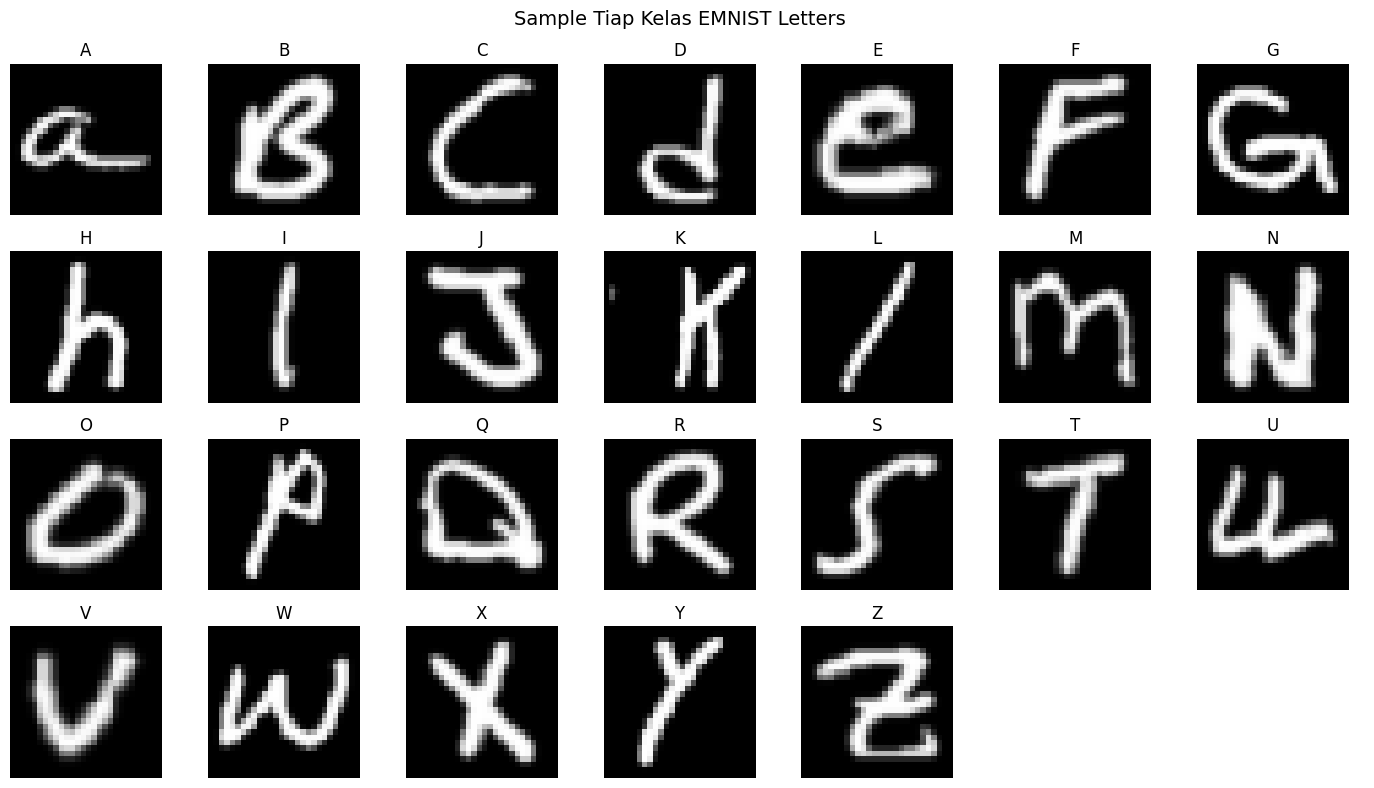

Visualisasi berhasil disimpan: sample_images.png


In [7]:
fig, axes = plt.subplots(4, 7, figsize=(14, 8))

for i, ax in enumerate(axes.flat):
    subset = balanced[balanced['label'] == i + 1]
    if len(subset) == 0:
        ax.axis('off')
        continue
    row_pixels = subset.iloc[0, 1:].values.astype(np.float32)
    img = preprocess_image(row_pixels)
    ax.imshow(img, cmap='gray')
    ax.set_title(chr(64 + (i + 1)))
    ax.axis('off')

plt.suptitle('Sample Tiap Kelas EMNIST Letters', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()
print("Visualisasi berhasil disimpan: sample_images.png")

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Normalisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape}")  # (2080, n_feat)
print(f"Test set : {X_test_scaled.shape}")   # (520, n_feat)

Train set: (2080, 1728)
Test set : (520, 1728)


In [9]:
param_grid = {
    'kernel': ['rbf', 'poly'],
    'C':      [0.1, 1, 10],
    'gamma':  ['scale', 'auto', 0.001]
}

svm = SVC(random_state=42)
grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("Memulai Grid Search, harap tunggu...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest params  : {grid_search.best_params_}")
print(f"Best CV acc  : {grid_search.best_score_:.4f}")

best_svm = grid_search.best_estimator_

Memulai Grid Search, harap tunggu...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best params  : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV acc  : 0.8010


In [10]:
print("Memulai LOOCV pada test set (520 sampel), harap tunggu...")
loo = LeaveOneOut()
loo_scores = cross_val_score(
    best_svm,
    X_test_scaled,
    y_test,
    cv=loo,
    scoring='accuracy',
    n_jobs=-1
)

print(f"LOOCV Accuracy : {loo_scores.mean():.4f}")
print(f"LOOCV Std Dev  : {loo_scores.std():.4f}")

Memulai LOOCV pada test set (520 sampel), harap tunggu...
LOOCV Accuracy : 0.6750
LOOCV Std Dev  : 0.4684


In [11]:
# Evaluasi Train Set
y_train_pred = best_svm.predict(X_train_scaled)
print("=" * 40)
print("EVALUASI TRAIN SET (80%)")
print("=" * 40)
print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_train, y_train_pred, average='weighted'):.4f}")

# Evaluasi Test Set
y_test_pred = best_svm.predict(X_test_scaled)
print("\n" + "=" * 40)
print("EVALUASI TEST SET (20%)")
print("=" * 40)
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print("\n" + "=" * 40)
print("CLASSIFICATION REPORT (TEST SET)")
print("=" * 40)
labels_str = [chr(64 + i) for i in range(1, 27)]
print(classification_report(y_test, y_test_pred, target_names=labels_str))

EVALUASI TRAIN SET (80%)
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

EVALUASI TEST SET (20%)
Accuracy : 0.8365
Precision: 0.8429
Recall   : 0.8365
F1-Score : 0.8344

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

           A       0.62      0.80      0.70        20
           B       0.74      0.85      0.79        20
           C       0.86      0.90      0.88        20
           D       0.93      0.65      0.76        20
           E       0.88      0.70      0.78        20
           F       0.90      0.90      0.90        20
           G       0.75      0.60      0.67        20
           H       0.87      0.65      0.74        20
           I       0.82      0.70      0.76        20
           J       0.69      0.90      0.78        20
           K       0.80      0.80      0.80        20
           L       0.81      0.85      0.83        20
           M       1.00      1.00      1.00        20
           N   

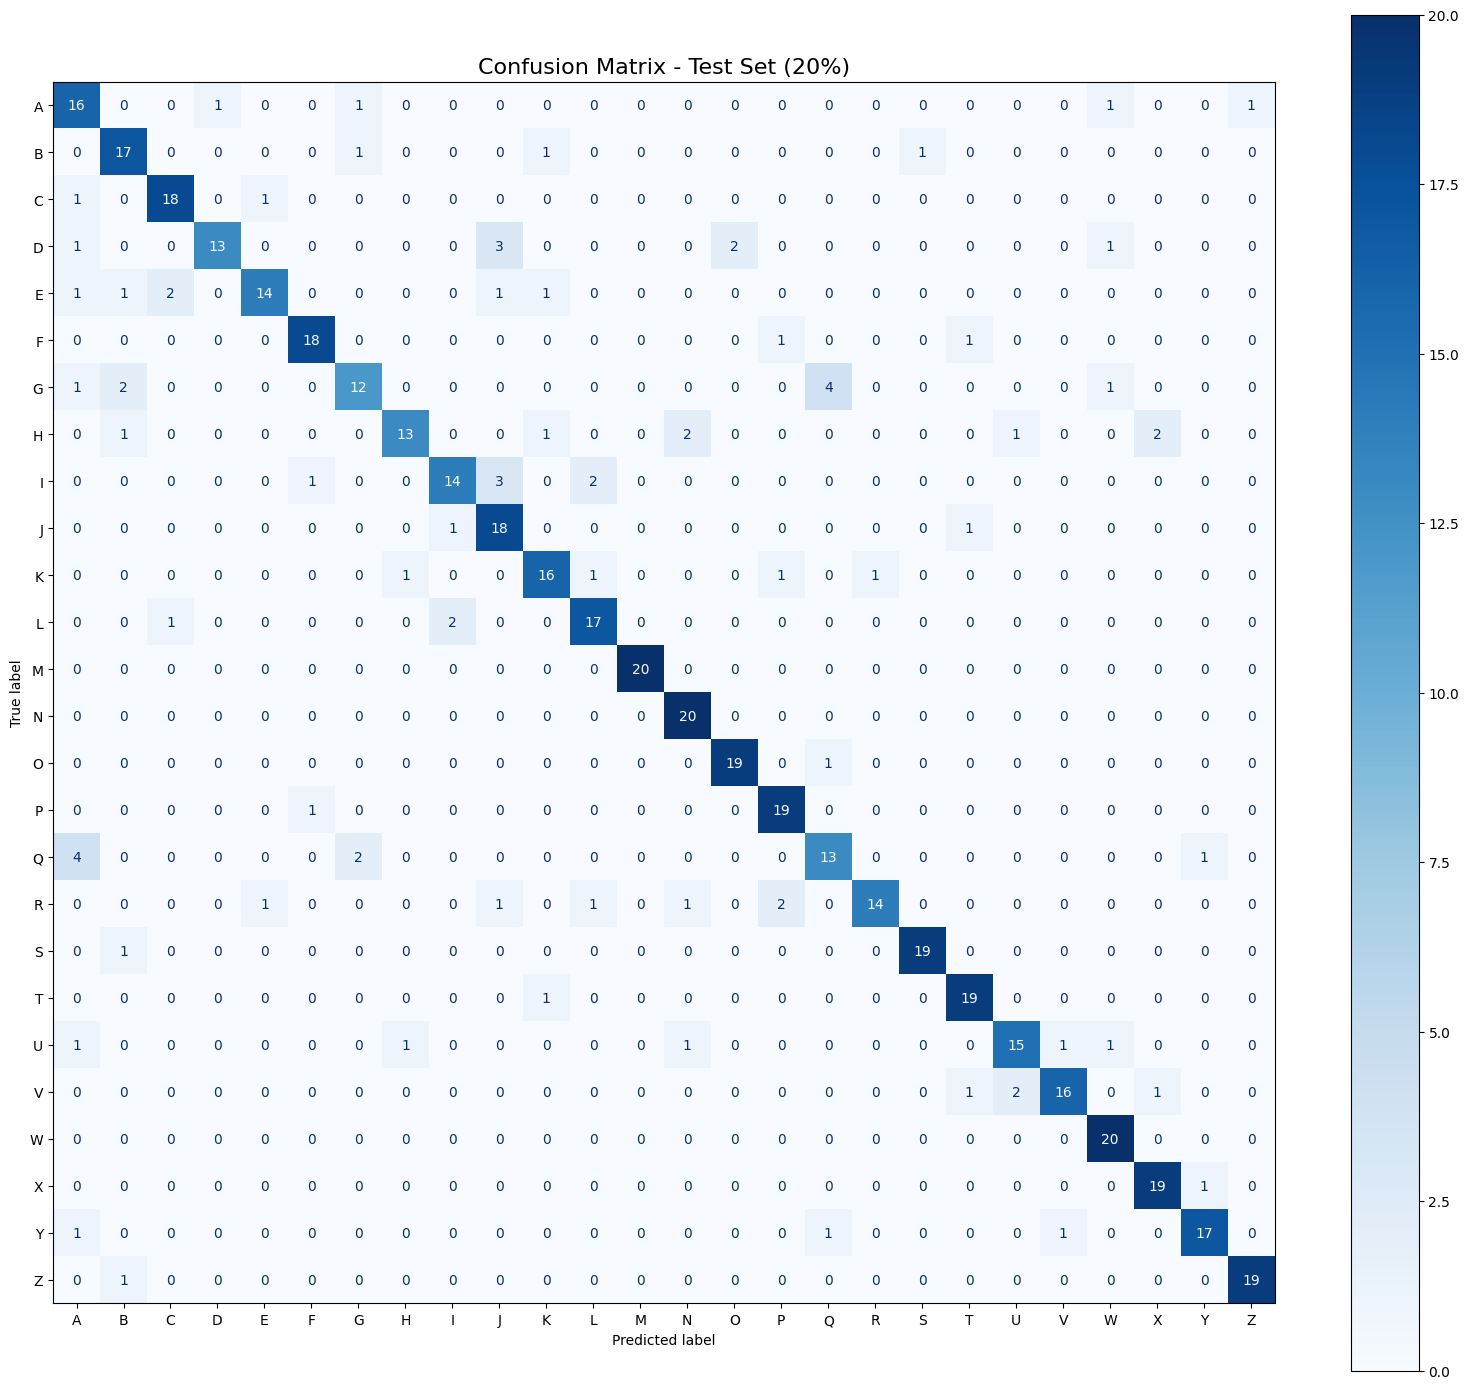

Confusion matrix berhasil disimpan: confusion_matrix.png


In [12]:
fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=[chr(64 + i) for i in range(1, 27)],
    ax=ax,
    colorbar=True,
    cmap='Blues'
)
ax.set_title('Confusion Matrix - Test Set (20%)', fontsize=16)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion matrix berhasil disimpan: confusion_matrix.png")